# Convolutional Neural Networks (CNNs)

CNNs exploit the spatial structure of images using weight sharing and local connectivity.

## 1. The Convolution Operation

Continuous convolution:
$$(f * g)(t) = \int_{-\infty}^{\infty} f(\tau) g(t - \tau) d\tau$$

Discrete 2D cross-correlation (used in CNNs):
$$(I * K)[i,j] = \sum_m \sum_n I[i+m, j+n] \cdot K[m,n]$$

**Note**: CNNs technically use cross-correlation (not flipped convolution), but call it "convolution" by convention.

## 2. Output Size Formula

$$W_{out} = \left\lfloor \frac{W_{in} - F + 2P}{S} \right\rfloor + 1$$

where:
- $W_{in}$: input width
- $F$: filter (kernel) size
- $P$: padding
- $S$: stride

**Parameters in a conv layer**: $(F \times F \times C_{in} + 1) \times C_{out}$ (includes bias)

## 3. Padding Types
- **Valid**: no padding, output smaller than input
- **Same**: padding added so output = input size (when stride=1)
- **Causal**: for sequences, pads only on the left

## 4. Receptive Field

The region of input that influences a single output neuron. Grows with depth:
$$RF_l = RF_{l-1} + (F_l - 1) \times \prod_{i=1}^{l-1} S_i$$

## 5. Pooling

Reduces spatial dimensions:
- **Max Pooling**: $\text{maxpool}(X) = \max_{i,j \in \text{window}} X[i,j]$
- **Average Pooling**: $\text{avgpool}(X) = \frac{1}{F^2}\sum_{i,j \in \text{window}} X[i,j]$
- **Global Average Pooling (GAP)**: averages entire feature map → scalar per channel

## 6. Dilated (Atrous) Convolution

Inserts spaces between kernel elements, expanding receptive field without more parameters:
$$(I *_d K)[i,j] = \sum_m \sum_n I[i + d\cdot m,\, j + d\cdot n] \cdot K[m,n]$$

Effective kernel size: $F_d = F + (F-1)(d-1)$. Used in WaveNet, DeepLab.

## 7. Depthwise Separable Convolution

Splits standard convolution into:
1. **Depthwise**: apply $C_{in}$ filters of shape $F \times F \times 1$ (one per channel)
2. **Pointwise**: apply $C_{out}$ filters of shape $1 \times 1 \times C_{in}$

Parameter reduction factor: $\frac{1}{C_{out}} + \frac{1}{F^2}$. Used in MobileNet.

## 8. Transposed Convolution (Deconvolution)

Upsamples feature maps (used in decoders, generators):
$$W_{out} = (W_{in} - 1) \times S - 2P + F$$

## 9. CNN Architectures

### LeNet-5 (LeCun, 1998)
First practical CNN. Architecture: C1→S2→C3→S4→C5→F6→Output

### AlexNet (Krizhevsky, 2012)
Won ImageNet 2012 by 10% margin. Introduced: ReLU, Dropout, data augmentation, GPU training.

### VGG (Simonyan & Zisserman, 2014)
Simple stacking of $3\times3$ conv layers. VGG-16 and VGG-19. Very deep but parameter-heavy.

### GoogLeNet / Inception (Szegedy, 2014)
**Inception module**: parallel branches with $1\times1$, $3\times3$, $5\times5$ convolutions + max pool, concatenated.
- $1\times1$ convolutions as **bottleneck** for dimensionality reduction.

### ResNet (He et al., 2015)
**Key innovation**: Residual (skip) connections:
$$\mathbf{H}(\mathbf{x}) = \mathcal{F}(\mathbf{x}) + \mathbf{x}$$

If the optimal mapping is close to identity, learning $\mathcal{F}(\mathbf{x})$ is easier (learn the **residual**).
Enables training of very deep networks (50, 101, 152, 1000+ layers). Solves vanishing gradient.

### DenseNet (Huang et al., 2017)
Every layer connected to all subsequent layers:
$$\mathbf{x}_l = H_l(\mathbf{x}_0, \mathbf{x}_1, ..., \mathbf{x}_{l-1})$$

### MobileNet (Howard et al., 2017)
Depthwise separable convolutions for **efficient mobile** deployment.
- MobileNetV2: inverted residuals + linear bottlenecks
- MobileNetV3: neural architecture search + hard-swish activation

### EfficientNet (Tan & Le, 2019)
**Compound scaling**: uniformly scales depth $d$, width $w$, resolution $r$:
$$d = \alpha^\phi,\quad w = \beta^\phi,\quad r = \gamma^\phi$$
subject to $\alpha \cdot \beta^2 \cdot \gamma^2 \approx 2$.

### ConvNeXt (Liu et al., 2022)
Pure CNN redesigned to match ViT performance. Uses depthwise conv 7×7, LayerNorm, GELU, inverted bottleneck.

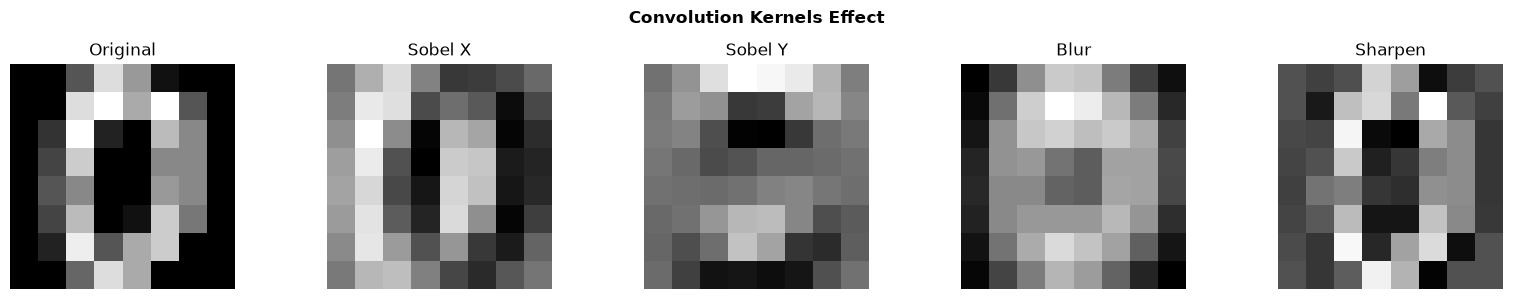

Output size formula demo:
  W_in=28, F=3, P=0, S=1 → W_out=26
  W_in=28, F=3, P=1, S=1 → W_out=28
  W_in=28, F=3, P=0, S=2 → W_out=13
  W_in=28, F=5, P=2, S=1 → W_out=28


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 2D Convolution from Scratch
# ============================================================

def conv2d_scratch(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = np.pad(image, padding, mode='constant')
    H, W = image.shape
    F = kernel.shape[0]
    H_out = (H - F) // stride + 1
    W_out = (W - F) // stride + 1
    output = np.zeros((H_out, W_out))
    for i in range(H_out):
        for j in range(W_out):
            patch = image[i*stride:i*stride+F, j*stride:j*stride+F]
            output[i, j] = np.sum(patch * kernel)
    return output

# Create test image
img = np.array([
    [1,2,3,0,1],
    [0,1,2,3,0],
    [1,0,1,2,3],
    [3,2,1,0,1],
    [0,1,3,2,1]
], dtype=float)

# Edge detection kernels
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=float)
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=float)
blur = np.ones((3,3))/9
sharpen = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]], dtype=float)

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
from PIL import Image as PILImage
try:
    from sklearn.datasets import load_digits
    digits = load_digits()
    img_real = digits.images[0]
except: img_real = img

for ax, (kernel, name) in zip(axes[1:], [(sobel_x,'Sobel X'),(sobel_y,'Sobel Y'),(blur,'Blur'),(sharpen,'Sharpen')]):
    out = conv2d_scratch(img_real, kernel, padding=1)
    ax.imshow(out, cmap='gray'); ax.set_title(name); ax.axis('off')
axes[0].imshow(img_real, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
plt.suptitle('Convolution Kernels Effect', fontweight='bold')
plt.tight_layout(); plt.show()

print('Output size formula demo:')
for F, P, S in [(3,0,1),(3,1,1),(3,0,2),(5,2,1)]:
    W_in = 28
    W_out = (W_in - F + 2*P) // S + 1
    print(f'  W_in={W_in}, F={F}, P={P}, S={S} → W_out={W_out}')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ---- ResNet block from scratch ----
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        # Shortcut: match dimensions if needed
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)   # Skip connection: H(x) = F(x) + x
        return self.relu(out)

# ---- Mini ResNet for CIFAR-10 ----
class MiniResNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True)
        )
        self.layer1 = ResidualBlock(32, 64, stride=2)
        self.layer2 = ResidualBlock(64, 128, stride=2)
        self.layer3 = ResidualBlock(128, 256, stride=2)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x).flatten(1)
        return self.fc(x)

model = MiniResNet(10)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

# Dummy forward pass
x = torch.randn(4, 3, 32, 32)
out = model(x)
print(f'Input: {x.shape} → Output: {out.shape}')

# ---- Depthwise Separable Conv demo ----
print('\n--- Depthwise Separable Convolution ---')
class DepthwiseSeparable(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, 3, stride=stride, padding=1, groups=in_ch, bias=False)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU6(inplace=True)

    def forward(self, x):
        return self.act(self.bn(self.pw(self.dw(x))))

standard_conv = nn.Conv2d(32, 64, 3, padding=1)
dw_sep_conv   = DepthwiseSeparable(32, 64)
print(f'Standard Conv params:   {sum(p.numel() for p in standard_conv.parameters()):,}')
print(f'Depthwise Sep params:   {sum(p.numel() for p in dw_sep_conv.parameters()):,}')
print(f'Reduction: {sum(p.numel() for p in standard_conv.parameters())/sum(p.numel() for p in dw_sep_conv.parameters()):.2f}x')

# ---- Transfer Learning ----
print('\n--- Transfer Learning with ResNet18 ---')
resnet = models.resnet18(pretrained=False)
# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False
# Replace final layer
resnet.fc = nn.Linear(resnet.fc.in_features, 5)  # 5 classes
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f'Trainable: {trainable:,} / Total: {total:,} ({100*trainable/total:.1f}%)')

MiniResNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): ResidualBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (layer2): ResidualBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), 

/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Additional Learning Resources

### Key Papers
- **LeNet-5** (LeCun et al., 1998): http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf
- **AlexNet** (Krizhevsky et al., 2012): https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf
- **VGG** (Simonyan & Zisserman, 2014): https://arxiv.org/abs/1409.1556
- **GoogLeNet/Inception** (Szegedy et al., 2014): https://arxiv.org/abs/1409.4842
- **ResNet** (He et al., 2015): https://arxiv.org/abs/1512.03385
- **DenseNet** (Huang et al., 2017): https://arxiv.org/abs/1608.06993
- **MobileNetV1** (Howard et al., 2017): https://arxiv.org/abs/1704.04861
- **MobileNetV2** (Sandler et al., 2018): https://arxiv.org/abs/1801.04381
- **EfficientNet** (Tan & Le, 2019): https://arxiv.org/abs/1905.11946
- **ConvNeXt** (Liu et al., 2022): https://arxiv.org/abs/2201.03545

### Courses & Blogs
- **Stanford CS231n**: http://cs231n.stanford.edu/
- **PyTorch Vision Tutorial**: https://pytorch.org/tutorials/beginner/transfer_learning_tutorial.html
- **CNN Explainer (interactive)**: https://poloclub.github.io/cnn-explainer/
- **Feature Visualization** Distill.pub: https://distill.pub/2017/feature-visualization/
- **Conv Arithmetic** (visual guide): https://github.com/vdumoulin/conv_arithmetic